# 01. ETL & Análise Exploratória de Dados (EDA)
**Projeto:** Retail Predictive Forecasting (Walmart M5)  

## Escopo Técnico
Este notebook executa o ciclo inicial de preparação de dados e análise diagnóstica. O objetivo é transformar dados brutos em um conjunto de dados enriquecido (camada Silver) e extrair os sinais fundamentais que guiarão a engenharia de features e o modelo de *Forecasting*.

## Pilares de Execução
1. **Pipeline de Dados (ETL):** Otimização de memória (*downcasting*), integração de bases (vendas, calendário, preços) e tratamento estrutural.
2. **Priorização de Valor:** Identificação do peso financeiro dos SKUs via Curva ABC (Pareto).
3. **Mapeamento Temporal:** Decomposição de ciclos de venda semanais e avaliação de impacto de feriados e eventos externos.
4. **Análise Hierárquica:** Diagnóstico de concentração de receita por Categorias, Departamentos (foco no `FOODS_3`), Lojas e Estados.

## Output
* Base consolidada (`sales_enriched_silver.parquet`) pronta para a fase de *Feature Engineering*.

In [71]:
from pathlib import Path
import kagglehub
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import matplotlib.ticker as mtick
from IPython.display import display

In [72]:
dest = Path("../data/bronze")
path = kagglehub.competition_download('m5-forecasting-accuracy')

shutil.copytree(path, dest, dirs_exist_ok=True)

print("Arquivos na pasta:", dest.resolve())

Arquivos na pasta: C:\Users\joaom\OneDrive\Desktop\retail-predictive-forecasting\data\bronze


In [73]:
for file in dest.glob("*.csv"):
    print(f"\n{file.name.upper()}")
    display(pd.read_csv(file, nrows=5))


CALENDAR.CSV


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1



SALES_TRAIN_EVALUATION.CSV


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0



SALES_TRAIN_VALIDATION.CSV


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4



SAMPLE_SUBMISSION.CSV


,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
0,HOBBIES_1_001_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,HOBBIES_1_002_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,HOBBIES_1_004_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,HOBBIES_1_005_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



SELL_PRICES.CSV


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


### Análise dos Arquivos e Suas Estruturas

- ##### A tabela **sales_train_evaluation** é a base principal, contendo 1941 colunas que representam a série temporal de vendas (cada coluna corresponde a um dia).

- ##### A tabela **calendar** possui a coluna **d**, que permite fazer o mapeamento temporal e enriquecer a tabela principal com informações de calendário.

- ##### A tabela **sell_prices** pode ser relacionada com a tabela principal por meio das colunas **store_id** e **item_id**, permitindo incorporar informações de preço à análise.

In [74]:

print("Carregando e otimizando a tabela de vendas")
dest = Path("../data/bronze")
df_sales = pd.read_csv(dest / 'sales_train_evaluation.csv')

id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
d_cols = [col for col in df_sales.columns if col.startswith('d_')]

for col in id_cols:
    df_sales[col] = df_sales[col].astype('category')

for col in d_cols:
    df_sales[col] = df_sales[col].astype('int16')

print(f"Tamanho original na memória: {df_sales.memory_usage().sum() / 1024**2:.2f} MB")

print("Realizando o Melt (Wide para Long)...")
df_melted = pd.melt(
    df_sales,
    id_vars=id_cols,
    value_vars=d_cols,
    var_name='d',      
    value_name='sales' 
)

df_melted['sales'] = df_melted['sales'].astype('int16')

print(f"Dimensões após o Melt (Mantendo os zeros): {df_melted.shape}")
print(f"Tamanho após o Melt na memória: {df_melted.memory_usage().sum() / 1024**2:.2f} MB")

print("Salvando na camada Silver em formato Parquet...")
silver_dest = Path("../data/silver")
silver_dest.mkdir(parents=True, exist_ok=True)

df_melted.to_parquet(silver_dest / 'sales_silver.parquet', index=False)

print("Base Silver salva!")
display(df_melted.head())

Carregando e otimizando a tabela de vendas


Tamanho original na memória: 114.44 MB
Realizando o Melt (Wide para Long)...
Dimensões após o Melt (Mantendo os zeros): (59181090, 8)
Tamanho após o Melt na memória: 1017.24 MB
Salvando na camada Silver em formato Parquet...
Base Silver salva!


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [75]:
dest = Path("../data/bronze")
silver_dest = Path("../data/silver")
df_melted = pd.read_parquet(silver_dest / 'sales_silver.parquet')

print("1. Carregando e tratando a tb Calendário...")
df_calendar = pd.read_csv(dest / 'calendar.csv', usecols=['d', 'wm_yr_wk', 'date'])
df_calendar['d'] = df_calendar['d'].astype('category')

print("2. Cruzando Vendas com a tb Calendário...")
df_merged = df_melted.merge(df_calendar, on='d', how='left')

del df_melted
gc.collect()

print("3. Carregando e otimizando Preços...")
df_prices = pd.read_csv(dest / 'sell_prices.csv')

df_prices['store_id'] = df_prices['store_id'].astype('category')
df_prices['item_id'] = df_prices['item_id'].astype('category')
df_prices['sell_price'] = df_prices['sell_price'].astype('float32')

print("4. Cruzando Vendas com Preços...")
df_merged = df_merged.merge(df_prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

del df_calendar, df_prices
gc.collect()

print("5. Calculando a Receita Bruta (Sales * Price)...")
df_merged['revenue'] = df_merged['sales'] * df_merged['sell_price']
df_merged['revenue'] = df_merged['revenue'].astype('float32')

df_merged['date'] = pd.to_datetime(df_merged['date'])

print("6. Salvando a base Silver enriquecida...")
df_merged.to_parquet(silver_dest / 'sales_enriched_silver.parquet', index=False)

display(df_merged.head())

1. Carregando e tratando a tb Calendário...
2. Cruzando Vendas com a tb Calendário...
3. Carregando e otimizando Preços...
4. Cruzando Vendas com Preços...
5. Calculando a Receita Bruta (Sales * Price)...
6. Salvando a base Silver enriquecida...


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,sell_price,revenue
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN


## 1. A Visão Macro: Evolução do Faturamento Geral
O ponto de partida. Aqui validamos o tamanho da operação e a tendência de longo prazo. O modelo preditivo precisa entender a base histórica, a inércia da demanda e os picos fora da curva antes de tentarmos prever o futuro no detalhe.

Analisando Tendência Macro...


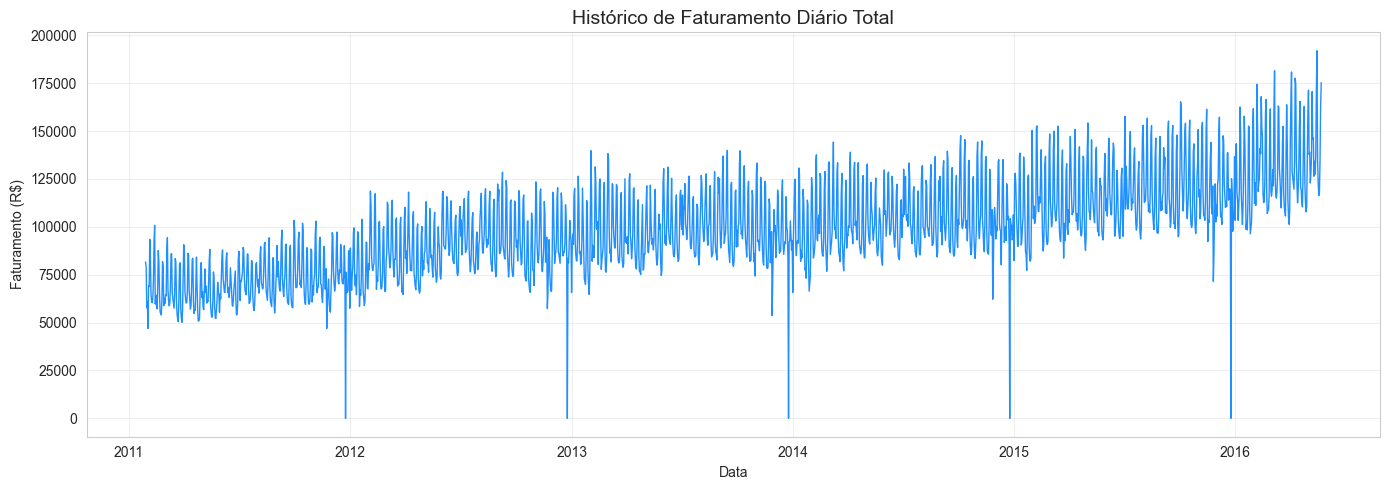

In [76]:
print("Analisando Tendência Macro...")

df_trend = df_merged.groupby('date', observed=True)['revenue'].sum().reset_index()

df_trend['dia_semana'] = df_trend['date'].dt.day_name()
df_trend['ano'] = df_trend['date'].dt.year

plt.figure(figsize=(14, 5))
sns.lineplot(data=df_trend, x='date', y='revenue', color='dodgerblue', linewidth=1)

plt.title('Histórico de Faturamento Diário Total', fontsize=14)
plt.ylabel('Faturamento (R$)')
plt.xlabel('Data')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

O ponto de partida. Aqui validamos o tamanho da operação e a tendência de longo prazo. O modelo precisa entender a base histórica antes de tentar prever qualquer coisa.

## 2. Comportamento Semanal
Olhando para o faturamento total, qual é o comportamento natural de compra? O pico evidente aos sábados e domingos mostra a sazonalidade bruta que o modelo terá que captar. Sem variáveis de calendário fortes, o algoritmo ficaria cego para o principal driver de tráfego nas lojas.

Analisando Sazonalidade Semanal e Dispersão...


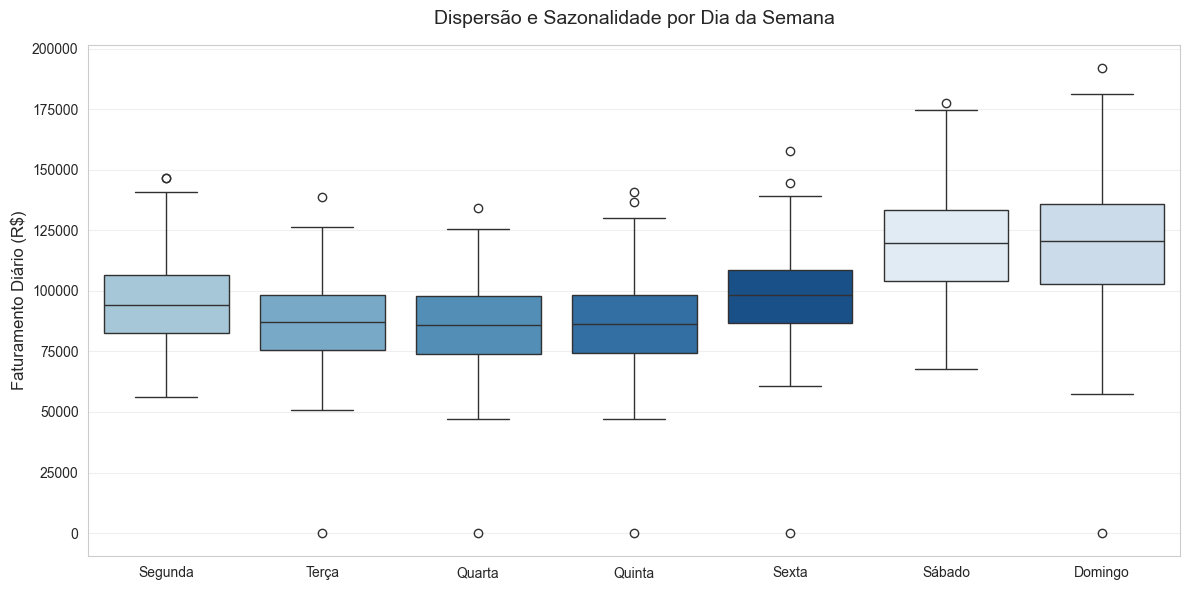

In [82]:
print("Analisando Sazonalidade Semanal e Dispersão...")

df_trend = df_merged.groupby('date', observed=True)['revenue'].sum().reset_index()

df_trend['dia_semana'] = df_trend['date'].dt.day_name()

traducao_dias = {
    'Monday': 'Segunda',
    'Tuesday': 'Terça',
    'Wednesday': 'Quarta',
    'Thursday': 'Quinta',
    'Friday': 'Sexta',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}

df_trend['dia_semana'] = df_trend['dia_semana'].map(traducao_dias)

ordem_dias_pt = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_trend, 
    x='dia_semana', 
    y='revenue', 
    order=ordem_dias_pt, 
    palette='Blues',
    hue='dia_semana', 
    legend=False     
)

plt.title('Dispersão e Sazonalidade por Dia da Semana', fontsize=14, pad=15)
plt.ylabel('Faturamento Diário (R$)', fontsize=12)
plt.xlabel('')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Olhando para o faturamento total, qual é o comportamento natural de compra? O pico aos sábados e domingos mostra a sazonalidade bruta que o modelo terá que captar.

## 3. O Peso dos Eventos e Feriados
**Objetivo:** Identificar o que tira a sazonalidade natural dos trilhos. Vamos mapear choques externos que injetam ou drenam receita, isolando o efeito de feriados específicos no faturamento diário.

1. Puxando os eventos do calendário...
2. Cruzando feriados com o faturamento diário...
3. Plotando o impacto dos feriados...


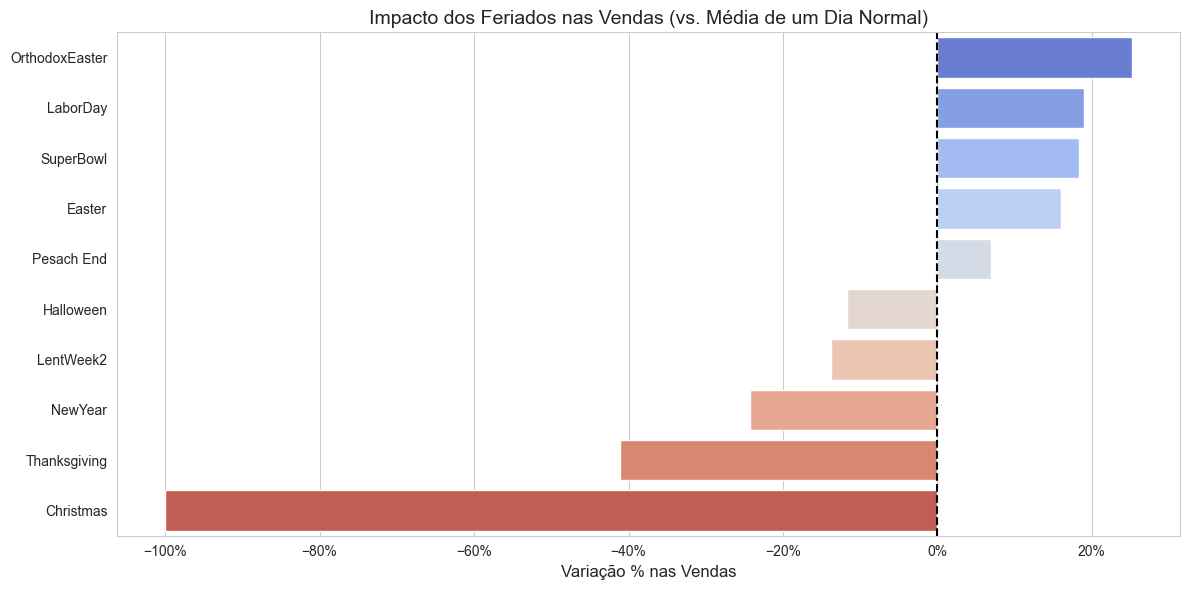

In [ ]:

print("1. Puxando os eventos do calendário...")
dest = Path("../data/bronze")

df_events = pd.read_csv(dest / 'calendar.csv', usecols=['date', 'event_name_1', 'event_type_1'])
df_events['date'] = pd.to_datetime(df_events['date'])

df_events = df_events.dropna(subset=['event_name_1'])

print("2. Cruzando feriados com o faturamento diário...")

df_holiday = df_trend.merge(df_events, on='date', how='inner')

media_dia_normal = df_trend[~df_trend['date'].isin(df_events['date'])]['revenue'].mean()

impacto = df_holiday.groupby('event_name_1', observed=True)['revenue'].mean().reset_index()

impacto['variacao_vs_normal'] = (impacto['revenue'] / media_dia_normal) - 1

impacto = impacto.sort_values(by='variacao_vs_normal', ascending=False)

top_positivos = impacto.head(5)
top_negativos = impacto.tail(5)
top_feriados = pd.concat([top_positivos, top_negativos])

print("3. Plotando o impacto dos feriados...")
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_feriados, 
    x='variacao_vs_normal', 
    y='event_name_1', 
    palette='coolwarm',
    hue='event_name_1',
    legend=False
)

plt.axvline(0, color='black', linewidth=1.5, linestyle='--')

plt.title('Impacto dos Feriados nas Vendas (vs. Média de um Dia Normal)', fontsize=14)
plt.xlabel('Variação % nas Vendas', fontsize=12)
plt.ylabel('')

plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

#### Diagnóstico de Eventos:
- **Outliers Positivos**: Eventos como Super Bowl e Labor Day são catalisadores de vendas.
- **Anomalia de Natal**: A queda de 100% confirma o fechamento das lojas, um ponto crítico para o treinamento do modelo.

## 4. Lojas e Estados
**Objetivo:** Começar a descer a granularidade da análise. Precisamos entender o tempo  de operação de cada filial e avaliar a disparidade de faturamento físico entre as unidades da Califórnia (CA), Texas (TX) e Wisconsin (WI) para determinar se precisaremos de variáveis categóricas de localização para calibrar o algoritmo.

Avaliando Idade das Lojas e Faturamento Médio Diário...

--- Validação de Tempo de Operação (Top 5 Lojas) ---


,store_id,primeira_venda,dias_operacao
2,CA_3,2011-01-29,1941
0,CA_1,2011-01-29,1941
5,TX_2,2011-01-29,1941
6,TX_3,2011-01-29,1941
8,WI_2,2011-01-29,1941


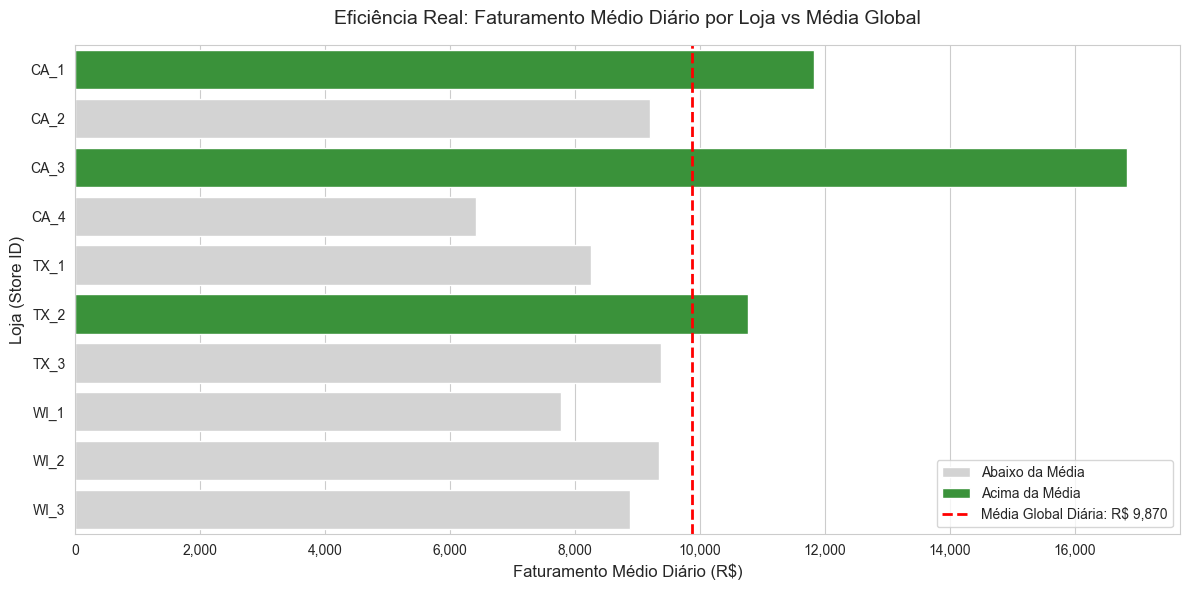

In [ ]:


print("Avaliando Idade das Lojas e Faturamento Médio Diário...")

df_store_perf = df_merged.groupby('store_id', observed=True).agg(
    primeira_venda=('date', 'min'),
    dias_operacao=('date', 'nunique'),
    faturamento_total=('revenue', 'sum')
).reset_index()

df_store_perf['faturamento_medio_diario'] = df_store_perf['faturamento_total'] / df_store_perf['dias_operacao']

df_store_perf = df_store_perf.sort_values(by='faturamento_medio_diario', ascending=False)

print("\n--- Validação de Tempo de Operação (Top 5 Lojas) ---")
display(df_store_perf[['store_id', 'primeira_venda', 'dias_operacao']].head())

media_global_diaria = df_store_perf['faturamento_medio_diario'].mean()
df_store_perf['acima_media'] = df_store_perf['faturamento_medio_diario'] >= media_global_diaria

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=df_store_perf, 
    x='faturamento_medio_diario', 
    y='store_id', 
    hue='acima_media',
    palette={True: '#2ca02c', False: '#d3d3d3'}, 
    dodge=False
)

ax.axvline(media_global_diaria, color='red', linestyle='--', linewidth=2, label=f'Média Global Diária: R$ {media_global_diaria:,.0f}')

plt.title('Eficiência Real: Faturamento Médio Diário por Loja vs Média Global', fontsize=14, pad=15)
plt.xlabel('Faturamento Médio Diário (R$)', fontsize=12)
plt.ylabel('Loja (Store ID)', fontsize=12)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[handles[0], handles[1], handles[2]], 
          labels=['Abaixo da Média', 'Acima da Média', f'Média Global Diária: R$ {media_global_diaria:,.0f}'], 
          loc='lower right')

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

* **Validação de Tempo de Operação:** A análise comprovou que todas as unidades operam pelo mesmo período (1.941 dias). Portanto, o volume de faturamento não possui viés de "idade da loja".
* **Desempenho Real (Tratores vs. Ofensores):** A performance reflete a eficiência e o fluxo puro de cada unidade. Temos 6 lojas puxando a rede para cima (lideradas com folga pela `CA_3` e `CA_1`), enquanto um grupo de 4 lojas opera como ofensoras da média (`WI_3`, `TX_1`, `WI_1` e a lanterna absoluta `CA_4`).
* **Impacto na Modelagem:** O algoritmo precisará da variável de localização (`store_id`) para calibrar o "intercepto" matemático de cada unidade. Prever a demanda da `CA_3` com a mesma régua basal da `CA_4` geraria um erro crônico de subestimação para a primeira e superestimação para a segunda.

## 5. Categorias
**Objetivo:** Já sabemos *onde* o dinheiro entra, mas *o que* essas lojas vendem? Vamos isolar os grandes blocos de produtos (FOODS, HOBBIES, HOUSEHOLD) para entender a composição da receita e a estabilidade da demanda ao longo do tempo.

Analisando Evolução do Faturamento por Categoria...


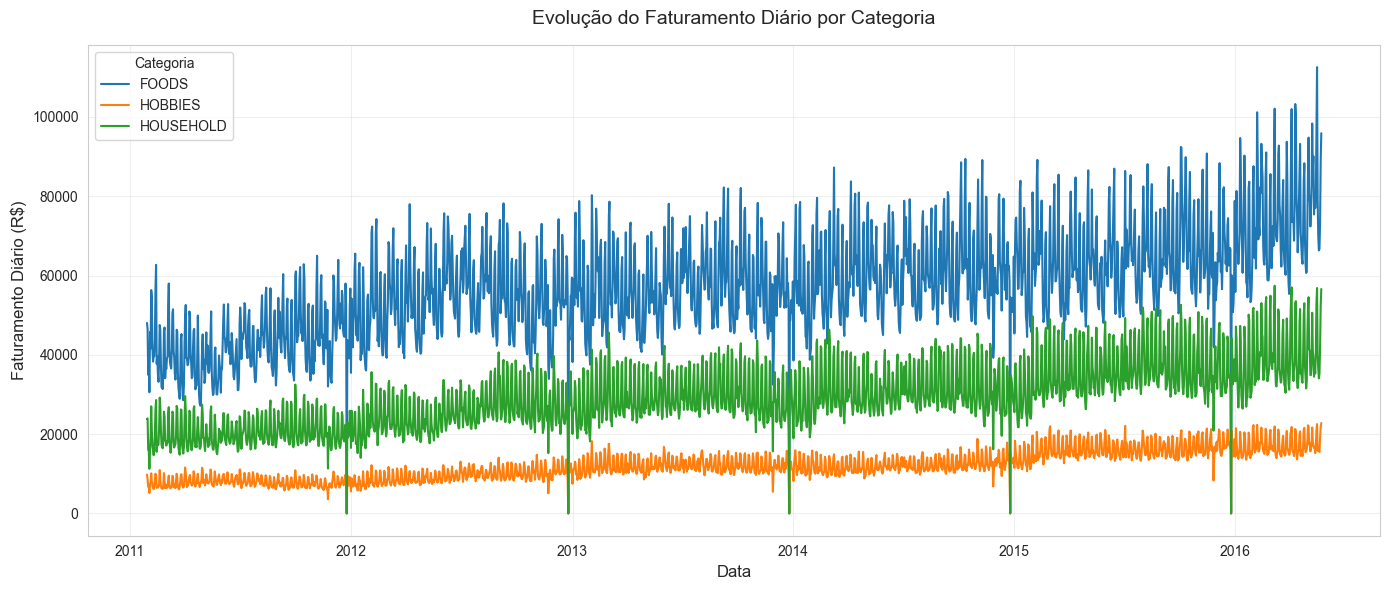

In [ ]:
print("Analisando Evolução do Faturamento por Categoria...")

df_cat_trend = df_merged.groupby(['date', 'cat_id'], observed=True)['revenue'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=df_cat_trend, 
    x='date', 
    y='revenue', 
    hue='cat_id', 
    palette='tab10', 
    linewidth=1.5
)

plt.title('Evolução do Faturamento Diário por Categoria', fontsize=14, pad=15)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Faturamento Diário (R$)', fontsize=12)
plt.legend(title='Categoria', loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

* **Categoria Destaque:** A categoria `FOODS` é a base estrutural do faturamento da rede, operando em um patamar financeiro isolado das demais. 
* **Estabilidade vs. Ruído:** Enquanto alimentos apresentam uma sazonalidade semanal muito bem delineada (aquelas "ondas" constantes) e alto volume, itens como `HOBBIES` têm vendas baixas. Na modelagem, isso significa que produtos de *Hobbies* terão séries temporais muito mais ruidosas e difíceis de prever no nível do item.

## 6. Sub-Categorias/Departamentos
**Objetivo:** Isolar os motores da receita. Agora que sabemos que a categoria `FOODS` domina, precisamos identificar exatamente qual subdepartamento concentra o maior volume financeiro e, consequentemente, o maior risco e peso para o modelo preditivo.

Analisando Faturamento por Departamento...


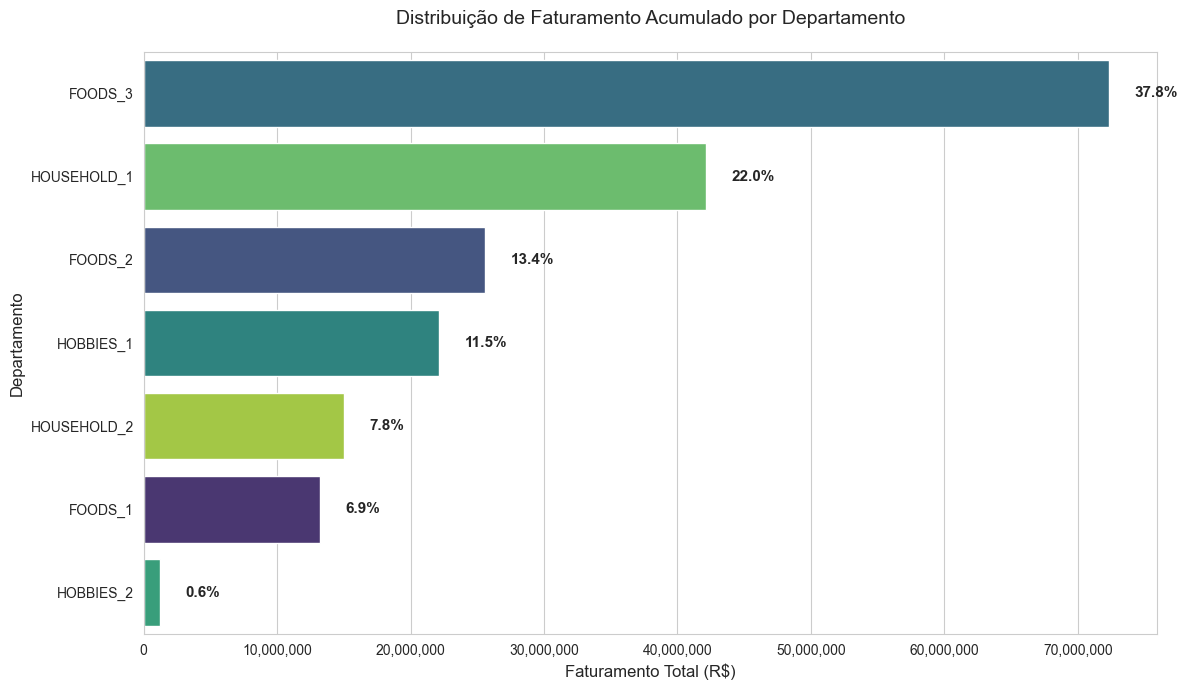

In [ ]:
print("Analisando Faturamento por Departamento...")

df_dept_vendas = df_merged.groupby('dept_id', observed=True)['revenue'].sum().sort_values(ascending=False).reset_index()

total_revenue = df_dept_vendas['revenue'].sum()
df_dept_vendas['share_percent'] = (df_dept_vendas['revenue'] / total_revenue) * 100

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=df_dept_vendas, 
    x='revenue', 
    y='dept_id', 
    palette='viridis', 
    hue='dept_id', 
    legend=False,
    order=df_dept_vendas['dept_id'] 
)

for index, row in df_dept_vendas.iterrows():
    ax.text(
        row['revenue'] + (total_revenue * 0.01), 
        index,                                   
        f'{row["share_percent"]:.1f}%',          
        va='center', 
        fontsize=11, 
        fontweight='bold'
    )

plt.title('Distribuição de Faturamento Acumulado por Departamento', fontsize=14, pad=20)
plt.xlabel('Faturamento Total (R$)', fontsize=12)
plt.ylabel('Departamento', fontsize=12)

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

* **O carro chefe:** O departamento `FOODS_3` é o protagonista absoluto, representando sozinho mais de um terço de toda a receita (37,8%). Ele possui um peso financeiro maior do que categorias inteiras de Lazer ou Casa somadas.

## 7. O Nível Micro: Curva ABC (Pareto)
**Objetivo:** O fundo do funil. No nível mais baixo de granularidade (SKU), vamos separar o sinal do ruído. Identificar os produtos de **Classe A** que sustentam o faturamento da rede para garantir que o modelo preditivo priorize a acurácia exatamente onde o impacto financeiro é maior.

Calculando o Pareto Financeiro (Curva ABC)...


,curva,qtd_skus,faturamento_total,%_skus,%_faturamento
0,A,1268,153250208.0,41.59,79.989998
1,B,924,28748080.0,30.31,15.010000
2,C,857,9579252.0,28.11,5.000000


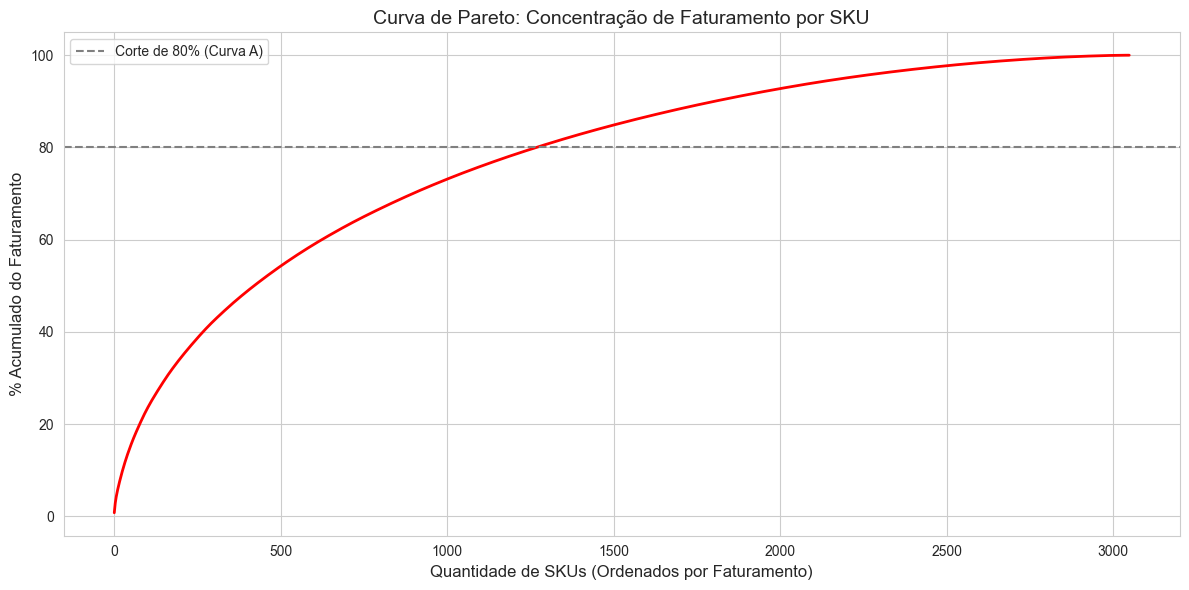

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Calculando o Pareto Financeiro (Curva ABC)...")

# Agrupando o faturamento total por produto
df_pareto = df_merged.groupby('item_id', observed=True)['revenue'].sum().reset_index()

# Ordenando do que mais vende pro que menos vende
df_pareto = df_pareto.sort_values(by='revenue', ascending=False)

# Calculando o percentual acumulado
df_pareto['perc_acumulado'] = (df_pareto['revenue'].cumsum() / df_pareto['revenue'].sum()) * 100

# Classificando na Curva ABC (A: até 80%, B: 80-95%, C: 95-100%)
def classifica_curva(perc):
    if perc <= 80: return 'A'
    elif perc <= 95: return 'B'
    else: return 'C'

df_pareto['curva'] = df_pareto['perc_acumulado'].apply(classifica_curva)

# Resumo da ópera
resumo_abc = df_pareto.groupby('curva').agg(
    qtd_skus=('item_id', 'count'),
    faturamento_total=('revenue', 'sum')
).reset_index()

resumo_abc['%_skus'] = (resumo_abc['qtd_skus'] / resumo_abc['qtd_skus'].sum()) * 100
resumo_abc['%_faturamento'] = (resumo_abc['faturamento_total'] / resumo_abc['faturamento_total'].sum()) * 100

display(resumo_abc.round(2))

# Plotando o gráfico de Pareto
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_pareto.reset_index(drop=True), x=df_pareto.reset_index(drop=True).index, y='perc_acumulado', color='red', linewidth=2)
plt.axhline(80, color='grey', linestyle='--', label='Corte de 80% (Curva A)')
plt.title('Curva de Pareto: Concentração de Faturamento por SKU', fontsize=14)
plt.xlabel('Quantidade de SKUs (Ordenados por Faturamento)', fontsize=12)
plt.ylabel('% Acumulado do Faturamento', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

* **Classe A:** Fica evidente que uma pequena parcela do portfólio (Classe A) é responsável por 80% de todo o faturamento da rede.

## 8. A Venda Zero
**Objetivo:** Objetivo: Validar o volume de zeros na base. Muitos produtos não vendem todo dia, e o modelo precisa saber lidar com esse "silêncio" nas prateleiras para não errar a previsão.

Analisando Intermitência de Vendas (Zeros)...


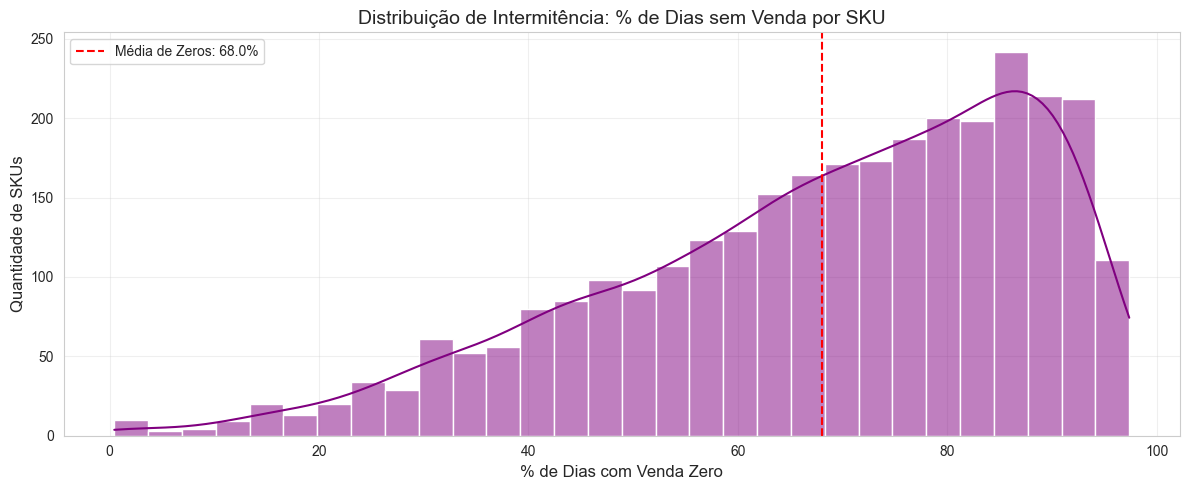

In [ ]:
print("Analisando Intermitência de Vendas (Zeros)...")

sparsity_check = df_merged.groupby('item_id', observed=True)['sales'].apply(lambda x: (x == 0).mean() * 100).reset_index()
sparsity_check.columns = ['item_id', 'zero_sales_percentage']

plt.figure(figsize=(12, 5))
sns.histplot(sparsity_check['zero_sales_percentage'], bins=30, kde=True, color='purple')

plt.axvline(sparsity_check['zero_sales_percentage'].mean(), color='red', linestyle='--', 
            label=f'Média de Zeros: {sparsity_check["zero_sales_percentage"].mean():.1f}%')

plt.title('Distribuição de Intermitência: % de Dias sem Venda por SKU', fontsize=14)
plt.xlabel('% de Dias com Venda Zero', fontsize=12)
plt.ylabel('Quantidade de SKUs', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

* **Venda Picada:** A grande maioria dos produtos passa mais de 50% do tempo sem vender nenhuma unidade. A venda não é um fluxo constante, é um evento que "salta".
* **Estratégia:** Como o dia a dia é muito instável (cheio de zeros), o segredo para o modelo não errar será olhar para a média das semanas. Assim, o "silêncio" de um dia não estraga a previsão do todo.

In [ ]:
# Salvando para a Feature
df_merged.to_parquet('../data/silver/sales_enriched_silver.parquet', index=False)
print("Base Silver salva com sucesso. Pronta para Feature Engineering!")

Base Silver salva com sucesso. Pronta para Feature Engineering!
